In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


**Konfigurasi dan Path Dataset**

In [3]:
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Cataract"  # Ganti dengan path sebenarnya

TRAIN_PATH = os.path.join(BASE_PATH, "Train")
TEST_PATH  = os.path.join(BASE_PATH, "Test")

# Cek folder
print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

# Hyperparameter
IMG_SIZE = 224          # Untuk EfficientNet dan VGG
BATCH_SIZE = 32
NUM_CLASSES = 2
EPOCHS_PHASE1 = 10      # Feature extraction
EPOCHS_PHASE2 = 10      # Fine-tuning
LR_PHASE1 = 1e-3
LR_PHASE2 = 1e-5
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# Nama kelas (harus sesuai dengan subfolder)
CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))  # ['cataract', 'normal']
print("Classes:", CLASS_NAMES)

Train folders: ['Cataract', 'Normal']
Test folders: ['Normal', 'Cataract']
Classes: ['Cataract', 'Normal']


**Data Augmentation & Transforms**

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


**Load Dataset dengan ImageFolder**

In [5]:
train_dataset = ImageFolder(root=TRAIN_PATH, transform=train_transforms)
test_dataset  = ImageFolder(root=TEST_PATH,  transform=test_transforms)

print(f"Jumlah train: {len(train_dataset)}")
print(f"Jumlah test : {len(test_dataset)}")
print("Distribusi kelas (train):", dict(zip(CLASS_NAMES, [sum(1 for _, y in train_dataset if y==i) for i in range(NUM_CLASSES)])))
print("Distribusi kelas (test) :", dict(zip(CLASS_NAMES, [sum(1 for _, y in test_dataset if y==i) for i in range(NUM_CLASSES)])))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

Jumlah train: 8068
Jumlah test : 1600
Distribusi kelas (train): {'Cataract': 3714, 'Normal': 4354}
Distribusi kelas (test) : {'Cataract': 800, 'Normal': 800}


**Tampilkan Sampel Gambar**

Sample training images:


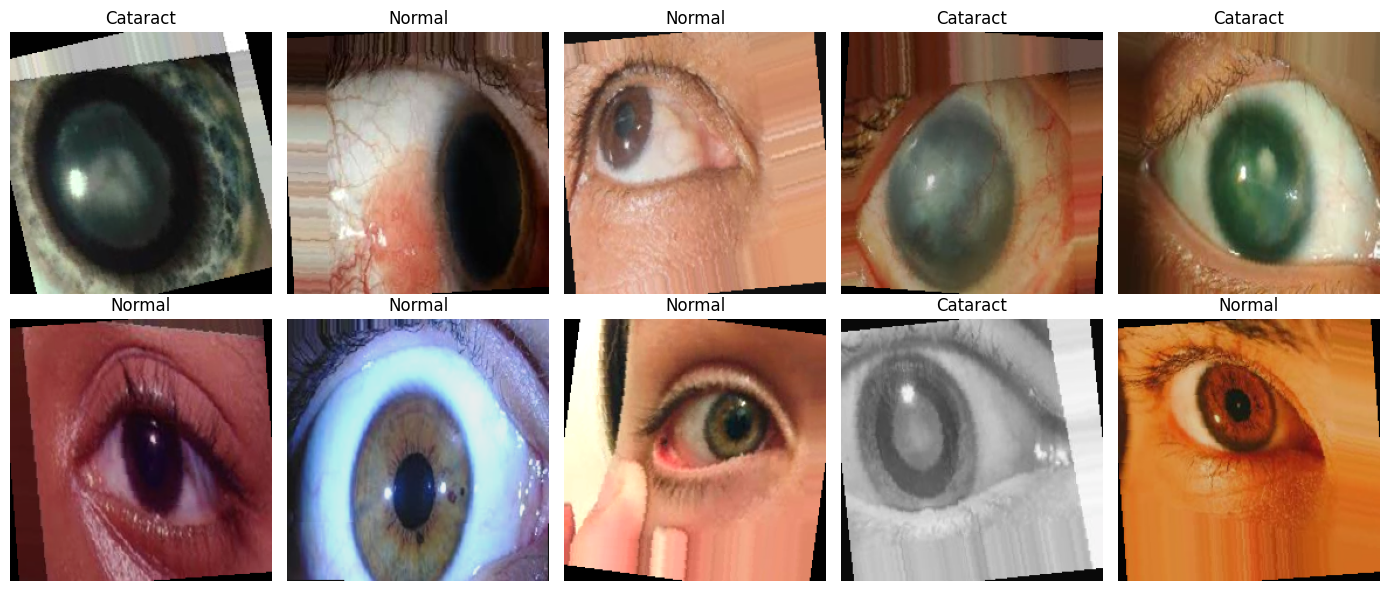

Sample test images:


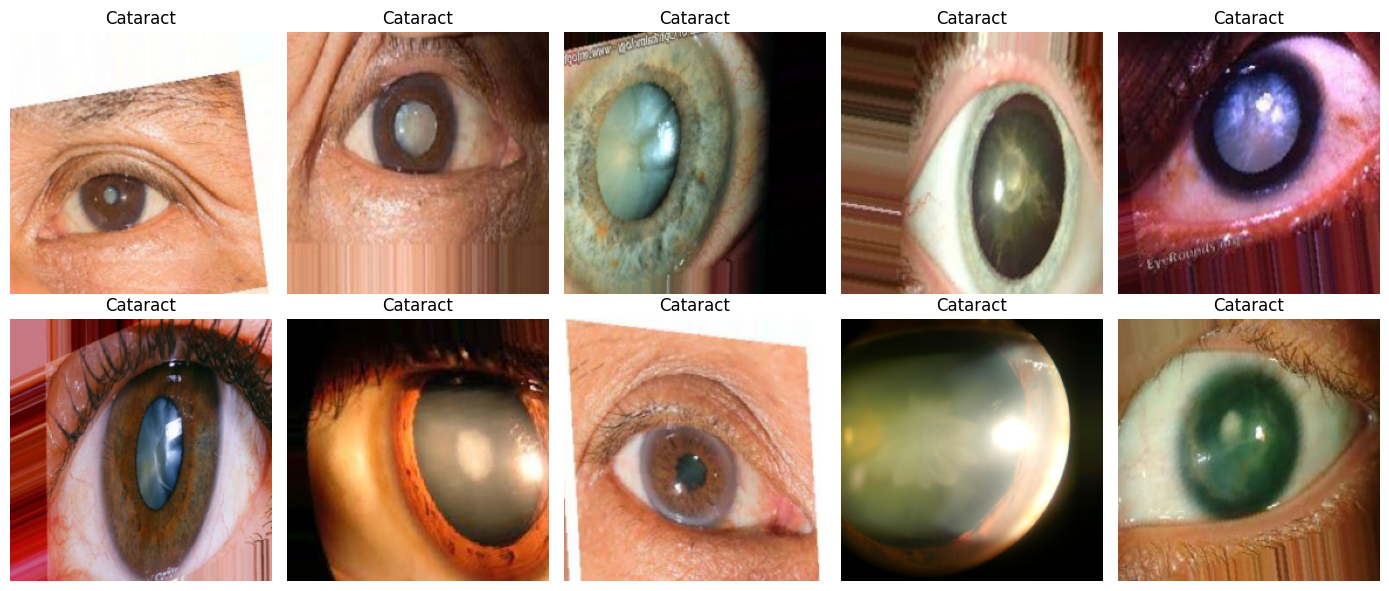

In [6]:
def show_samples(loader, class_names, n=10):
    images, labels = next(iter(loader))
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = (images[:n] * std + mean).clamp(0,1).permute(0,2,3,1).numpy()
    fig, axes = plt.subplots(2, 5, figsize=(14,6))
    for i, ax in enumerate(axes.flat):
        if i < len(imgs):
            ax.imshow(imgs[i])
            ax.set_title(class_names[labels[i]])
            ax.axis("off")
    plt.tight_layout()
    plt.show()

print("Sample training images:")
show_samples(train_loader, CLASS_NAMES)
print("Sample test images:")
show_samples(test_loader, CLASS_NAMES)

**Fungsi Training dan Evaluasi**

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def train_model(model, train_loader, test_loader, criterion, optimizer,
                epochs, device, model_name="Model"):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, test_loader, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}  ({elapsed:.1f}s)")

    model.load_state_dict(best_state)
    print(f"\n✅ Best val accuracy: {best_acc:.4f}")
    return history

def plot_history(history, model_name="Model"):
    epochs = range(1, len(history["train_loss"])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="red")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="green")
    axes[0].set_title(f"{model_name} – Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="red")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   color="green")
    axes[1].set_title(f"{model_name} – Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, loader, class_names, device, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} – Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return all_labels, all_preds

**Definisi Model**

In [8]:
def freeze_backbone(model, arch):
    if arch == "efficientnet_b3":
        for param in model.features.parameters():
            param.requires_grad = False
    elif arch == "vgg16":
        for param in model.features.parameters():
            param.requires_grad = False
    elif arch == "inception_v3":
        for name, param in model.named_parameters():
            if "fc" not in name and "AuxLogits" not in name:
                param.requires_grad = False

def unfreeze_for_finetune(model, arch):
    if arch == "efficientnet_b3":
        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "features.6" in name or "features.7" in name or "classifier" in name:
                param.requires_grad = True
    elif arch == "vgg16":
        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "features.24" in name or "features.26" in name or "features.28" in name or "classifier" in name:
                param.requires_grad = True
    elif arch == "inception_v3":
        for param in model.parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if "Mixed_7" in name or "fc" in name:
                param.requires_grad = True

def build_model(arch, num_classes, freeze=True):
    if arch == "efficientnet_b3":
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes)
        )
    elif arch == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier = nn.Sequential(
            *list(model.classifier.children())[:-1],
            nn.Dropout(p=0.4),
            nn.Linear(4096, num_classes)
        )
    elif arch == "inception_v3":
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1,
                                    aux_logits=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.fc.in_features, num_classes)
        )
    else:
        raise ValueError(f"Unknown arch: {arch}")

    if freeze:
        freeze_backbone(model, arch)
    return model.to(device)

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params : {trainable:,}  /  Total: {total:,}  ({100*trainable/total:.1f}%)")

**Training EfficientNetB3**

*Phase 1*


EfficientNetB3 – Feature Extraction
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 180MB/s]


Trainable params : 3,074  /  Total: 10,699,306  (0.0%)
[EfficientNetB3-P1] Epoch 01/10  train_loss=0.3073  train_acc=0.8906  val_loss=0.2007  val_acc=0.9287  (79.2s)
[EfficientNetB3-P1] Epoch 02/10  train_loss=0.1992  train_acc=0.9248  val_loss=0.1713  val_acc=0.9337  (76.3s)
[EfficientNetB3-P1] Epoch 03/10  train_loss=0.1775  train_acc=0.9328  val_loss=0.1643  val_acc=0.9350  (75.5s)
[EfficientNetB3-P1] Epoch 04/10  train_loss=0.1689  train_acc=0.9360  val_loss=0.1415  val_acc=0.9463  (76.0s)
[EfficientNetB3-P1] Epoch 05/10  train_loss=0.1590  train_acc=0.9394  val_loss=0.1427  val_acc=0.9475  (77.7s)
[EfficientNetB3-P1] Epoch 06/10  train_loss=0.1611  train_acc=0.9370  val_loss=0.1293  val_acc=0.9519  (77.7s)
[EfficientNetB3-P1] Epoch 07/10  train_loss=0.1592  train_acc=0.9390  val_loss=0.1382  val_acc=0.9494  (78.4s)
[EfficientNetB3-P1] Epoch 08/10  train_loss=0.1507  train_acc=0.9419  val_loss=0.1323  val_acc=0.9519  (78.4s)
[EfficientNetB3-P1] Epoch 09/10  train_loss=0.1526  train

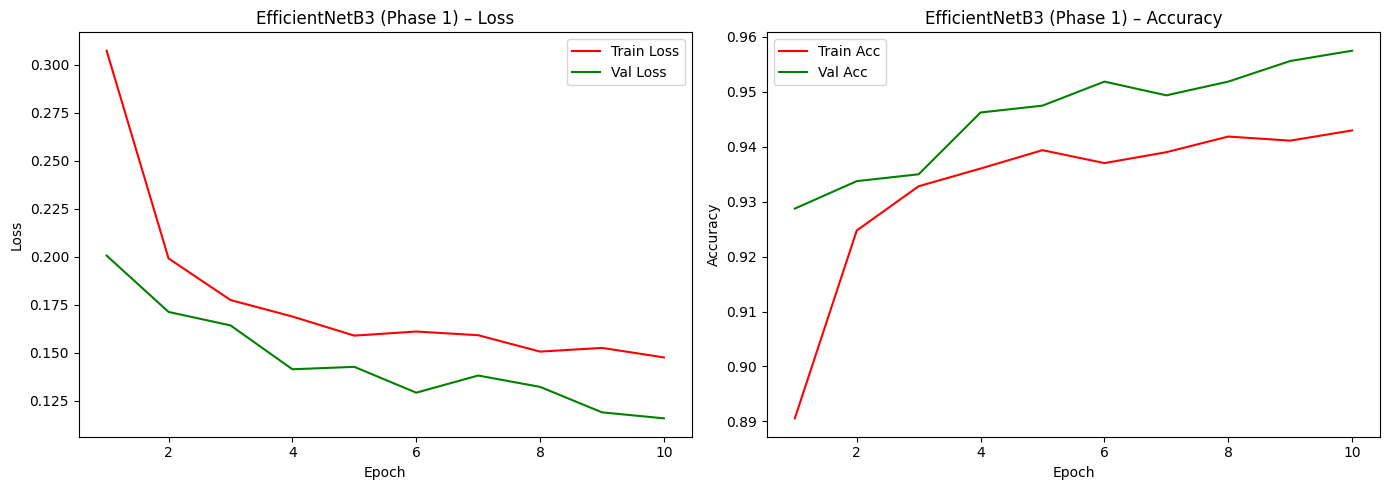

In [9]:
print("\n" + "="*50)
print("EfficientNetB3 – Feature Extraction")
print("="*50)
model_ef = build_model("efficientnet_b3", NUM_CLASSES, freeze=True)
count_trainable_params(model_ef)

criterion = nn.CrossEntropyLoss()
optimizer_ef = optim.Adam(filter(lambda p: p.requires_grad, model_ef.parameters()), lr=LR_PHASE1)

history_ef_p1 = train_model(model_ef, train_loader, test_loader, criterion, optimizer_ef,
                            EPOCHS_PHASE1, device, "EfficientNetB3-P1")
plot_history(history_ef_p1, "EfficientNetB3 (Phase 1)")

*Fine Tunning*


EfficientNetB3 – Fine-tuning
Trainable params : 7,916,256  /  Total: 10,699,306  (74.0%)
[EfficientNetB3-P2] Epoch 01/10  train_loss=0.1275  train_acc=0.9520  val_loss=0.0915  val_acc=0.9656  (112.6s)
[EfficientNetB3-P2] Epoch 02/10  train_loss=0.0995  train_acc=0.9636  val_loss=0.0678  val_acc=0.9781  (123.8s)
[EfficientNetB3-P2] Epoch 03/10  train_loss=0.0783  train_acc=0.9734  val_loss=0.0502  val_acc=0.9844  (103.1s)
[EfficientNetB3-P2] Epoch 04/10  train_loss=0.0697  train_acc=0.9746  val_loss=0.0433  val_acc=0.9850  (83.9s)
[EfficientNetB3-P2] Epoch 05/10  train_loss=0.0584  train_acc=0.9797  val_loss=0.0309  val_acc=0.9900  (83.6s)
[EfficientNetB3-P2] Epoch 06/10  train_loss=0.0532  train_acc=0.9807  val_loss=0.0338  val_acc=0.9875  (81.5s)
[EfficientNetB3-P2] Epoch 07/10  train_loss=0.0455  train_acc=0.9840  val_loss=0.0229  val_acc=0.9919  (84.3s)
[EfficientNetB3-P2] Epoch 08/10  train_loss=0.0408  train_acc=0.9865  val_loss=0.0258  val_acc=0.9900  (82.6s)
[EfficientNetB3-P2]

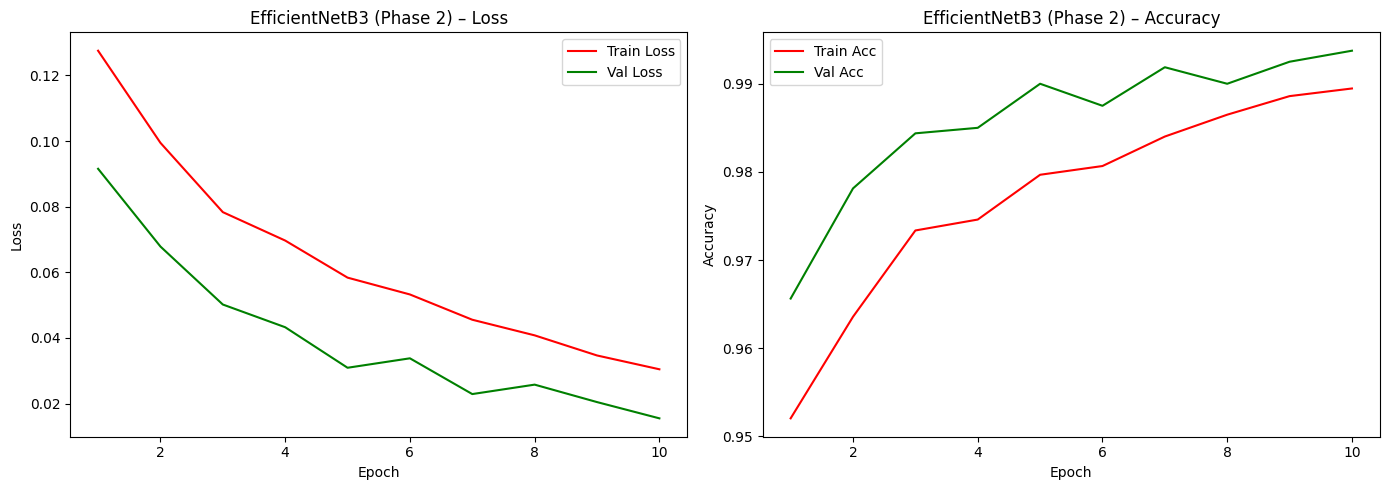


Evaluasi EfficientNetB3 pada test set:


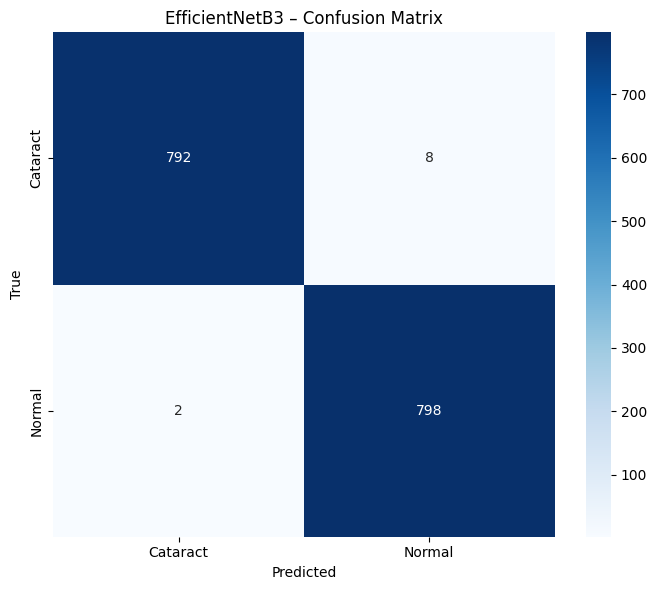

              precision    recall  f1-score   support

    Cataract       1.00      0.99      0.99       800
      Normal       0.99      1.00      0.99       800

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



([np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64

In [10]:
print("\n" + "="*50)
print("EfficientNetB3 – Fine-tuning")
print("="*50)
unfreeze_for_finetune(model_ef, "efficientnet_b3")
count_trainable_params(model_ef)
optimizer_ef2 = optim.Adam(filter(lambda p: p.requires_grad, model_ef.parameters()), lr=LR_PHASE2)

history_ef_p2 = train_model(model_ef, train_loader, test_loader, criterion, optimizer_ef2,
                            EPOCHS_PHASE2, device, "EfficientNetB3-P2")
plot_history(history_ef_p2, "EfficientNetB3 (Phase 2)")

# Evaluasi akhir EfficientNetB3
print("\nEvaluasi EfficientNetB3 pada test set:")
plot_confusion_matrix(model_ef, test_loader, CLASS_NAMES, device, "EfficientNetB3")

**Training VGG16**

*Phase 1*


VGG16 – Feature Extraction
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 182MB/s]


Trainable params : 119,554,050  /  Total: 134,268,738  (89.0%)
[VGG16-P1] Epoch 01/10  train_loss=0.7076  train_acc=0.8824  val_loss=0.3693  val_acc=0.9519  (89.6s)
[VGG16-P1] Epoch 02/10  train_loss=0.8568  train_acc=0.9281  val_loss=0.1821  val_acc=0.9694  (88.0s)
[VGG16-P1] Epoch 03/10  train_loss=0.6496  train_acc=0.9500  val_loss=0.1788  val_acc=0.9794  (89.9s)
[VGG16-P1] Epoch 04/10  train_loss=0.5150  train_acc=0.9608  val_loss=0.1416  val_acc=0.9819  (89.5s)
[VGG16-P1] Epoch 05/10  train_loss=0.5921  train_acc=0.9585  val_loss=0.5967  val_acc=0.9631  (88.0s)
[VGG16-P1] Epoch 06/10  train_loss=0.6289  train_acc=0.9636  val_loss=0.3270  val_acc=0.9756  (88.1s)
[VGG16-P1] Epoch 07/10  train_loss=0.6675  train_acc=0.9658  val_loss=0.1142  val_acc=0.9875  (88.3s)
[VGG16-P1] Epoch 08/10  train_loss=0.6258  train_acc=0.9706  val_loss=0.5369  val_acc=0.9731  (88.3s)
[VGG16-P1] Epoch 09/10  train_loss=0.6265  train_acc=0.9729  val_loss=0.2198  val_acc=0.9869  (88.7s)
[VGG16-P1] Epoch 10

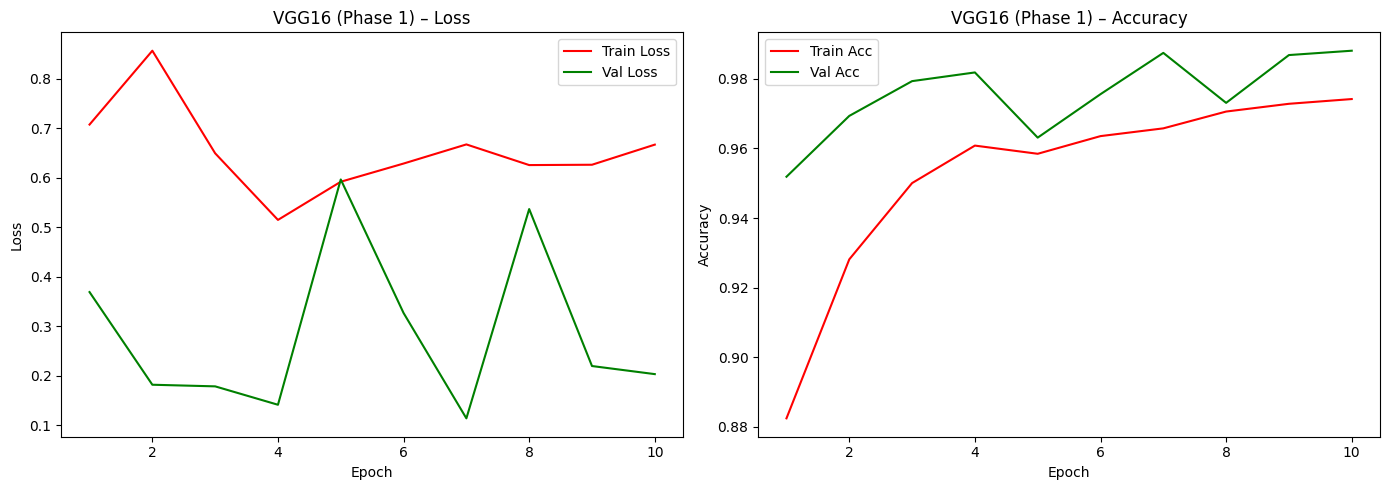

In [11]:
print("\n" + "="*50)
print("VGG16 – Feature Extraction")
print("="*50)
model_vgg = build_model("vgg16", NUM_CLASSES, freeze=True)
count_trainable_params(model_vgg)

optimizer_vgg = optim.Adam(filter(lambda p: p.requires_grad, model_vgg.parameters()), lr=LR_PHASE1)
history_vgg_p1 = train_model(model_vgg, train_loader, test_loader, criterion, optimizer_vgg,
                             EPOCHS_PHASE1, device, "VGG16-P1")
plot_history(history_vgg_p1, "VGG16 (Phase 1)")

*Fine Tunning*


VGG16 – Fine-tuning
Trainable params : 126,633,474  /  Total: 134,268,738  (94.3%)
[VGG16-P2] Epoch 01/10  train_loss=0.2598  train_acc=0.9838  val_loss=0.0564  val_acc=0.9931  (91.4s)
[VGG16-P2] Epoch 02/10  train_loss=0.1112  train_acc=0.9900  val_loss=0.0514  val_acc=0.9944  (90.7s)
[VGG16-P2] Epoch 03/10  train_loss=0.0983  train_acc=0.9911  val_loss=0.0393  val_acc=0.9962  (90.0s)
[VGG16-P2] Epoch 04/10  train_loss=0.0597  train_acc=0.9927  val_loss=0.0324  val_acc=0.9950  (89.5s)
[VGG16-P2] Epoch 05/10  train_loss=0.0524  train_acc=0.9929  val_loss=0.0335  val_acc=0.9962  (89.9s)
[VGG16-P2] Epoch 06/10  train_loss=0.0483  train_acc=0.9939  val_loss=0.0340  val_acc=0.9956  (89.7s)
[VGG16-P2] Epoch 07/10  train_loss=0.0249  train_acc=0.9960  val_loss=0.0197  val_acc=0.9962  (91.0s)
[VGG16-P2] Epoch 08/10  train_loss=0.0245  train_acc=0.9963  val_loss=0.0252  val_acc=0.9962  (90.0s)
[VGG16-P2] Epoch 09/10  train_loss=0.0173  train_acc=0.9967  val_loss=0.0419  val_acc=0.9956  (90.4s

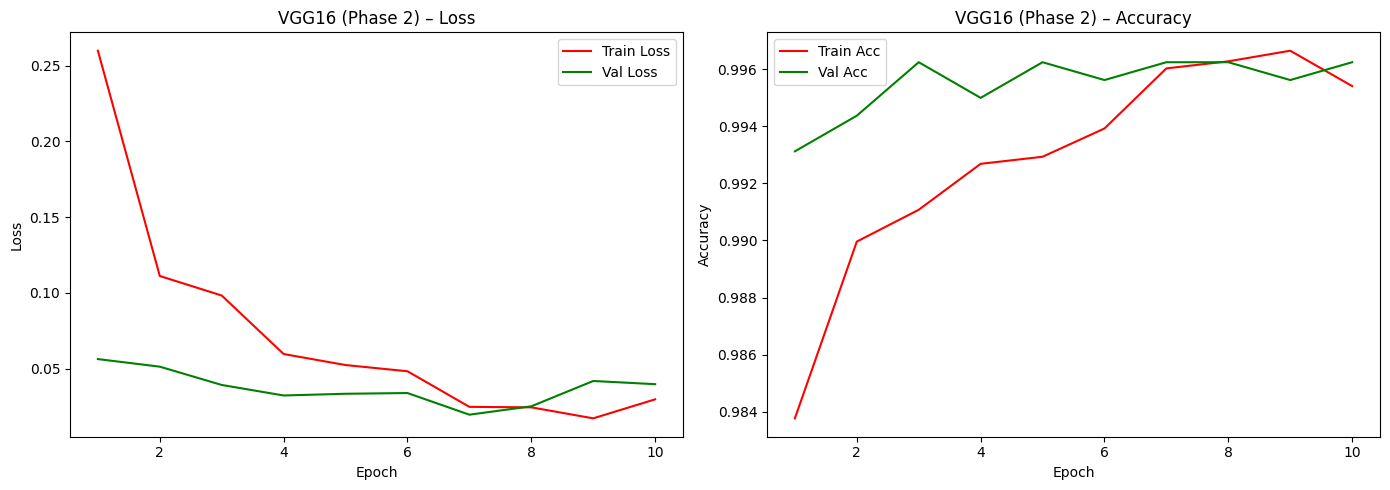


Evaluasi VGG16 pada test set:


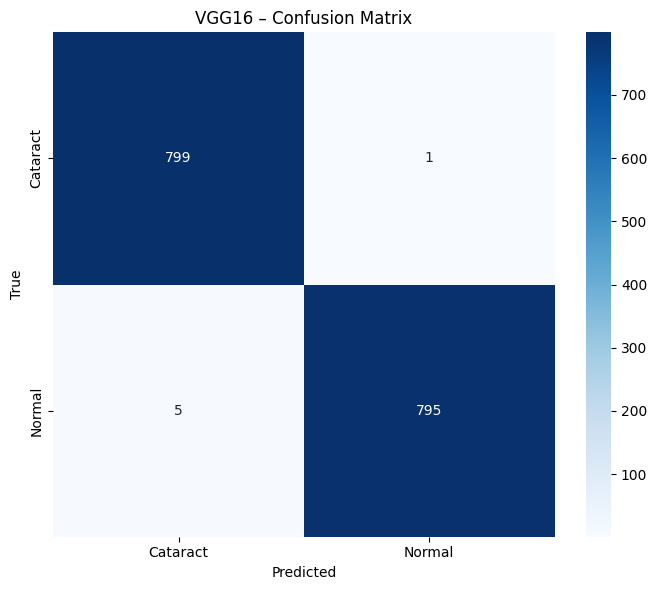

              precision    recall  f1-score   support

    Cataract       0.99      1.00      1.00       800
      Normal       1.00      0.99      1.00       800

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



([np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64

In [12]:
print("\n" + "="*50)
print("VGG16 – Fine-tuning")
print("="*50)
unfreeze_for_finetune(model_vgg, "vgg16")
count_trainable_params(model_vgg)
optimizer_vgg2 = optim.Adam(filter(lambda p: p.requires_grad, model_vgg.parameters()), lr=LR_PHASE2)

history_vgg_p2 = train_model(model_vgg, train_loader, test_loader, criterion, optimizer_vgg2,
                             EPOCHS_PHASE2, device, "VGG16-P2")
plot_history(history_vgg_p2, "VGG16 (Phase 2)")

print("\nEvaluasi VGG16 pada test set:")
plot_confusion_matrix(model_vgg, test_loader, CLASS_NAMES, device, "VGG16")

**Perbandingan Akhir**

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


📊 PERBANDINGAN AKHIR ANTARA MODEL

🔍 Mengumpulkan metrik dari test set...

📋 Tabel Perbandingan Metrik:
         Model  Accuracy  Precision  Recall  F1-Score
EfficientNetB3   0.99375   0.990074 0.99750  0.993773
         VGG16   0.99625   0.998744 0.99375  0.996241


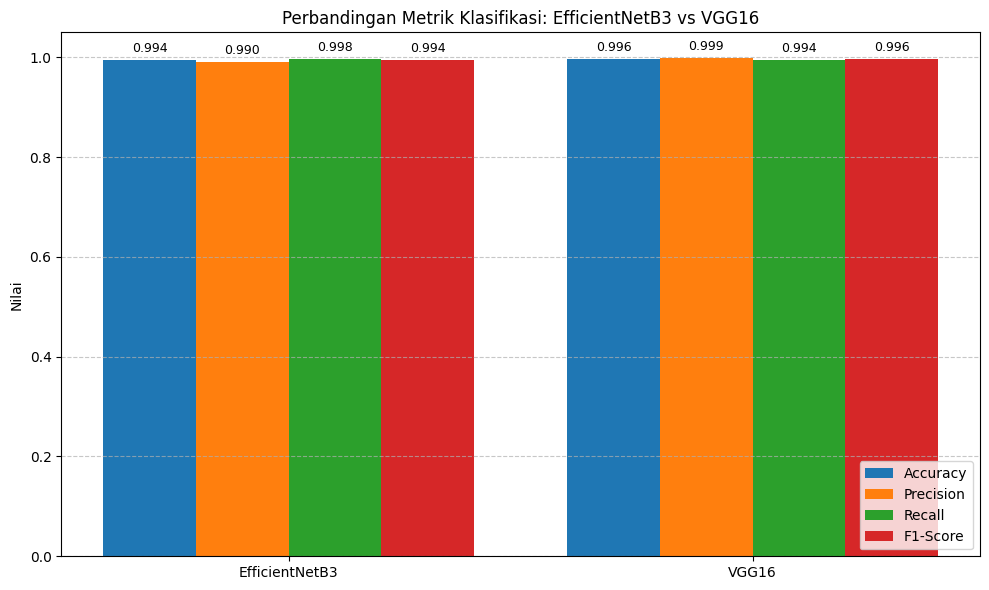

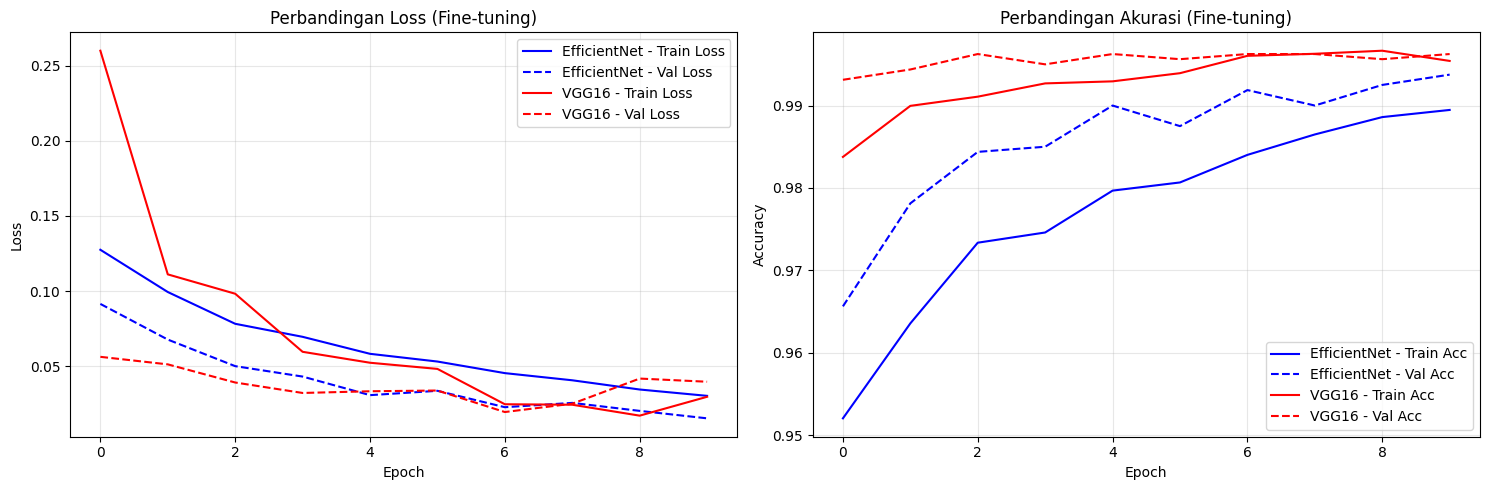

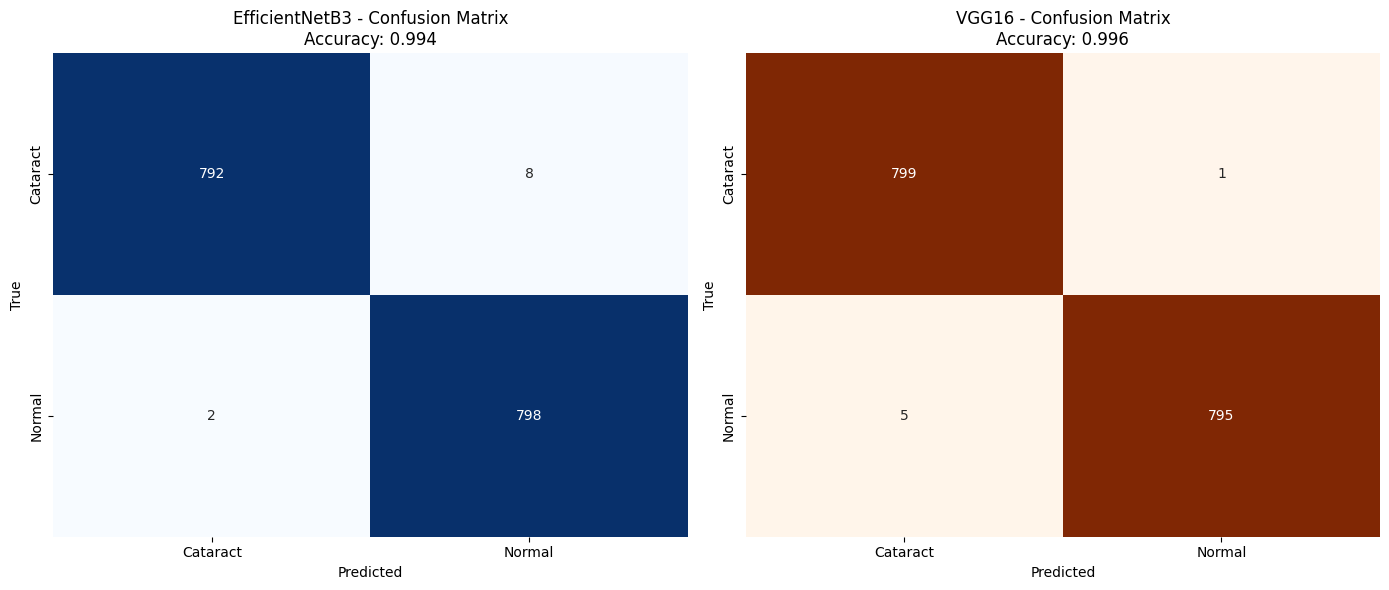


📌 KESIMPULAN AKHIR
🏆 Best model by Recall: EfficientNetB3
   Accuracy  : 0.994
   Precision : 0.990
   Recall    : 0.998
   F1-Score  : 0.994

📌 Rekomendasi:
Model EfficientNetB3 menunjukkan performa terbaik dengan Recall 0.998.
Model ini dapat digunakan untuk sistem klasifikasi katarak (cataract vs normal).

Untuk pengembangan selanjutnya, pertimbangkan:
- Eksperimen dengan arsitektur lain (ResNet, DenseNet, InceptionV3)
- Data augmentation lebih agresif untuk mengurangi overfitting
- Menggunakan class weight jika distribusi data tidak seimbang
- Implementasi pada dataset yang lebih besar dan beragam



In [38]:
# 10. Perbandingan Akhir (Final Comparison)

print("\n" + "="*60)
print("📊 PERBANDINGAN AKHIR ANTARA MODEL")
print("="*60)

# --- 10.1. Evaluasi Ulang pada Test Set untuk Mendapatkan Metrik Lengkap ---
def get_metrics(model, loader, device):
    """Menghitung accuracy, precision, recall, f1-score dari model pada loader."""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary')
    recall = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels
    }

print("\n🔍 Mengumpulkan metrik dari test set...")

# Ambil metrik untuk EfficientNetB3
metrics_ef = get_metrics(model_ef, test_loader, device)

# Ambil metrik untuk VGG16
metrics_vgg = get_metrics(model_vgg, test_loader, device)

# Buat DataFrame perbandingan
results_df = pd.DataFrame({
    'Model': ['EfficientNetB3', 'VGG16'],
    'Accuracy': [metrics_ef['accuracy'], metrics_vgg['accuracy']],
    'Precision': [metrics_ef['precision'], metrics_vgg['precision']],
    'Recall': [metrics_ef['recall'], metrics_vgg['recall']],
    'F1-Score': [metrics_ef['f1'], metrics_vgg['f1']]
})

print("\n📋 Tabel Perbandingan Metrik:")
print(results_df.to_string(index=False))

# --- 10.2. Visualisasi Perbandingan Metrik (Bar Chart) ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df['Model']))
width = 0.2
multiplier = 0

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics_to_plot):
    offset = width * (i - 1.5)
    bars = ax.bar(x + offset, results_df[metric], width, label=metric, color=colors[i])
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Metrik Klasifikasi: EfficientNetB3 vs VGG16')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 10.3. Perbandingan Kurva Training (Loss & Accuracy) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
axes[0].plot(history_ef_p2['train_loss'], label='EfficientNet - Train Loss', color='blue', linestyle='-')
axes[0].plot(history_ef_p2['val_loss'], label='EfficientNet - Val Loss', color='blue', linestyle='--')
axes[0].plot(history_vgg_p2['train_loss'], label='VGG16 - Train Loss', color='red', linestyle='-')
axes[0].plot(history_vgg_p2['val_loss'], label='VGG16 - Val Loss', color='red', linestyle='--')
axes[0].set_title('Perbandingan Loss (Fine-tuning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(history_ef_p2['train_acc'], label='EfficientNet - Train Acc', color='blue', linestyle='-')
axes[1].plot(history_ef_p2['val_acc'], label='EfficientNet - Val Acc', color='blue', linestyle='--')
axes[1].plot(history_vgg_p2['train_acc'], label='VGG16 - Train Acc', color='red', linestyle='-')
axes[1].plot(history_vgg_p2['val_acc'], label='VGG16 - Val Acc', color='red', linestyle='--')
axes[1].set_title('Perbandingan Akurasi (Fine-tuning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 10.4. Perbandingan Confusion Matrix Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix EfficientNetB3
cm_ef = confusion_matrix(metrics_ef['labels'], metrics_ef['predictions'])
sns.heatmap(cm_ef, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], cbar=False)
axes[0].set_title(f'EfficientNetB3 - Confusion Matrix\nAccuracy: {metrics_ef["accuracy"]:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confusion Matrix VGG16
cm_vgg = confusion_matrix(metrics_vgg['labels'], metrics_vgg['predictions'])
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], cbar=False)
axes[1].set_title(f'VGG16 - Confusion Matrix\nAccuracy: {metrics_vgg["accuracy"]:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# --- 10.5. Kesimpulan Akhir ---
print("\n" + "="*60)
print("📌 KESIMPULAN AKHIR")
print("="*60)

# Tentukan model terbaik berdasarkan Recall (atau metrik lain)
best_model = results_df.loc[results_df['Recall'].idxmax()]
best_model_name = best_model['Model']
best_recall = best_model['Recall']

print(f"🏆 Best model by Recall: {best_model_name}")
print(f"   Accuracy  : {best_model['Accuracy']:.3f}")
print(f"   Precision : {best_model['Precision']:.3f}")
print(f"   Recall    : {best_model['Recall']:.3f}")
print(f"   F1-Score  : {best_model['F1-Score']:.3f}")

print(f"""
📌 Rekomendasi:
Model {best_model_name} menunjukkan performa terbaik dengan Recall {best_recall:.3f}.
Model ini dapat digunakan untuk sistem klasifikasi katarak (cataract vs normal).

Untuk pengembangan selanjutnya, pertimbangkan:
- Eksperimen dengan arsitektur lain (ResNet, DenseNet, InceptionV3)
- Data augmentation lebih agresif untuk mengurangi overfitting
- Menggunakan class weight jika distribusi data tidak seimbang
- Implementasi pada dataset yang lebih besar dan beragam
""")

**save model**

In [58]:
torch.save(model_ef.state_dict(), 'efficientnet_cataract.pth')
torch.save(model_vgg.state_dict(), 'vgg_cataract.pth')

In [46]:
!pip install efficientnet-pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=ec01560e126d579112683a0d774ba0fff4ff3aba32525e99ba3ca53899b99d44
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch


In [50]:
!pip install onnxscript onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 6.9 MB/s eta 0:00:00


In [51]:
import torch.onnx

In [53]:
# --- CONVERT TO ONNX (OPSET 9, CPU, TANPA CONSTANT FOLDING) ---
import torch.onnx

model_ef_cpu = model_ef.cpu().eval()
model_vgg_cpu = model_vgg.cpu().eval()
dummy = torch.randn(1, 3, 224, 224)

# EfficientNet
torch.onnx.export(
    model_ef_cpu,
    dummy,
    "efficientnet_cataract.onnx",
    opset_version=9,
    input_names=['input'],
    output_names=['output'],
    export_params=True,
    do_constant_folding=False,  # Hindari masalah folding
)

# VGG
torch.onnx.export(
    model_vgg_cpu,
    dummy,
    "vgg_cataract.onnx",
    opset_version=9,
    input_names=['input'],
    output_names=['output'],
    export_params=True,
    do_constant_folding=False,
)

print("ONNX models saved successfully!")

W0616 13:40:16.970000 267 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 9 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0616 13:40:18.744000 267 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0616 13:40:18.746000 267 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'i

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Obtain model graph for `VGG([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VGG([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX models saved successfully!


In [61]:
%whos

Variable                 Type                Data/Info
------------------------------------------------------
BASE_PATH                str                 /content/drive/MyDrive/Colab Notebooks/Cataract
BATCH_SIZE               int                 32
CLASS_NAMES              list                n=2
DataLoader               type                <class 'torch.utils.data.dataloader.DataLoader'>
Dataset                  type                <class 'torch.utils.data.dataset.Dataset'>
EPOCHS_PHASE1            int                 10
EPOCHS_PHASE2            int                 10
IMAGENET_MEAN            list                n=3
IMAGENET_STD             list                n=3
IMG_SIZE                 int                 224
ImageFolder              type                <class 'torchvision.datasets.folder.ImageFolder'>
LR_PHASE1                float               0.001
LR_PHASE2                float               1e-05
NUM_CLASSES              int                 2
SEED                     int   